# CIFAR-10 KNN Classification: L1 vs L2

This notebook implements a KNN classifier on the CIFAR-10 dataset and compares two distance metrics: L1 (Manhattan distance) and L2 (Euclidean distance).

To keep runtime manageable, the experiment uses a subset of the training and test data. Increase `TRAIN_LIMIT`, `TEST_LIMIT`, or `K_VALUES` for larger experiments.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

RESULT_DIR = Path('results')
RESULT_DIR.mkdir(exist_ok=True)

CIFAR10_LABELS = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

## 1. Load and Preprocess Data

In [ ]:
try:
    from tensorflow.keras.datasets import cifar10
except ImportError as exc:
    raise ImportError(
        'TensorFlow is required to load CIFAR-10 automatically. '
        'Install command: pip install tensorflow'
    ) from exc

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.ravel()
y_test = y_test.ravel()

print('Train:', x_train.shape, y_train.shape)
print('Test :', x_test.shape, y_test.shape)

Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


In [3]:
TRAIN_LIMIT = 5000
TEST_LIMIT = 1000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)
train_idx = rng.choice(len(x_train), size=TRAIN_LIMIT, replace=False)
test_idx = rng.choice(len(x_test), size=TEST_LIMIT, replace=False)

x_train_small = x_train[train_idx]
y_train_small = y_train[train_idx]
x_test_small = x_test[test_idx]
y_test_small = y_test[test_idx]

# KNN computes distances between pixel vectors, so each 32x32x3 image is flattened into a 3072-dimensional vector.
X_train = x_train_small.reshape(TRAIN_LIMIT, -1).astype(np.float32) / 255.0
X_test = x_test_small.reshape(TEST_LIMIT, -1).astype(np.float32) / 255.0

print('Flattened train:', X_train.shape)
print('Flattened test :', X_test.shape)

Flattened train: (5000, 3072)
Flattened test : (1000, 3072)


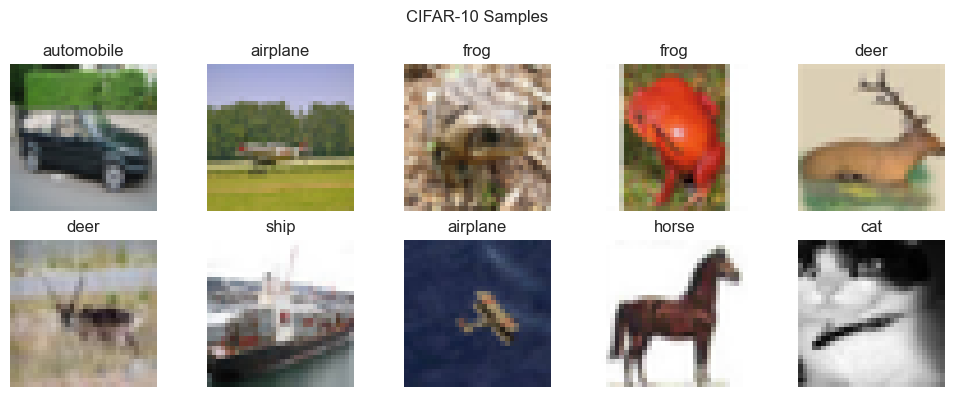

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), x_train_small[:10], y_train_small[:10]):
    ax.imshow(image)
    ax.set_title(CIFAR10_LABELS[label])
    ax.axis('off')
fig.suptitle('CIFAR-10 Samples')
fig.tight_layout()
fig.savefig(RESULT_DIR / '5_cifar10_samples.png', dpi=150)
plt.show()

## 2. Implement KNN Functions

In [6]:
def vote_labels(neighbor_labels, num_classes=10):
    predictions = np.empty(neighbor_labels.shape[0], dtype=np.int64)
    for i, labels in enumerate(neighbor_labels):
        counts = np.bincount(labels, minlength=num_classes)
        predictions[i] = counts.argmax()
    return predictions


def l2_distances(test_batch, train_data):
    test_sq = np.sum(test_batch * test_batch, axis=1, keepdims=True)
    train_sq = np.sum(train_data * train_data, axis=1)
    distances_sq = test_sq + train_sq - 2.0 * test_batch @ train_data.T
    return np.sqrt(np.maximum(distances_sq, 0.0))


def l1_distances(test_batch, train_data, train_chunk_size=500):
    distances = np.empty((len(test_batch), len(train_data)), dtype=np.float32)
    for start in range(0, len(train_data), train_chunk_size):
        end = min(start + train_chunk_size, len(train_data))
        distances[:, start:end] = np.abs(
            test_batch[:, None, :] - train_data[None, start:end, :]
        ).sum(axis=2)
    return distances


def knn_predict_many_k(train_data, train_labels, test_data, k_values, metric='l2', batch_size=50):
    max_k = max(k_values)
    predictions_by_k = {k: [] for k in k_values}
    for start in range(0, len(test_data), batch_size):
        end = min(start + batch_size, len(test_data))
        test_batch = test_data[start:end]

        if metric == 'l2':
            distances = l2_distances(test_batch, train_data)
        elif metric == 'l1':
            distances = l1_distances(test_batch, train_data)
        else:
            raise ValueError("metric must be 'l1' or 'l2'")

        neighbor_idx = np.argpartition(distances, kth=max_k - 1, axis=1)[:, :max_k]
        sorted_order = np.take_along_axis(distances, neighbor_idx, axis=1).argsort(axis=1)
        neighbor_idx = np.take_along_axis(neighbor_idx, sorted_order, axis=1)
        neighbor_labels = train_labels[neighbor_idx]

        for k in k_values:
            predictions_by_k[k].append(vote_labels(neighbor_labels[:, :k]))

    return {k: np.concatenate(predictions) for k, predictions in predictions_by_k.items()}

## 3. Compare L1 and L2 Distance Metrics

In [7]:
K_VALUES = [1, 3, 5, 7]
METRICS = ['l1', 'l2']

results = []

for metric in METRICS:
    start_time = perf_counter()
    predictions_by_k = knn_predict_many_k(
        X_train, y_train_small, X_test, k_values=K_VALUES, metric=metric, batch_size=50
    )
    elapsed = perf_counter() - start_time

    for k, y_pred in predictions_by_k.items():
        accuracy = np.mean(y_pred == y_test_small)
        results.append({
            'metric': metric.upper(),
            'k': k,
            'accuracy': accuracy,
            'time_sec': elapsed,
        })
        print(f"{metric.upper()} / k={k}: accuracy={accuracy:.4f}, metric_time={elapsed:.2f}s")

L1 / k=1: accuracy=0.2820, metric_time=42.21s
L1 / k=3: accuracy=0.2730, metric_time=42.21s
L1 / k=5: accuracy=0.2690, metric_time=42.21s
L1 / k=7: accuracy=0.2760, metric_time=42.21s
L2 / k=1: accuracy=0.2660, metric_time=0.59s
L2 / k=3: accuracy=0.2730, metric_time=0.59s
L2 / k=5: accuracy=0.2760, metric_time=0.59s
L2 / k=7: accuracy=0.2670, metric_time=0.59s


In [8]:
try:
    import pandas as pd

    result_df = pd.DataFrame(results)
    display(result_df)
except ImportError:
    result_df = results
    for row in results:
        print(row)

,metric,k,accuracy,time_sec
0,L1,1,0.282,42.206236
1,L1,3,0.273,42.206236
2,L1,5,0.269,42.206236
3,L1,7,0.276,42.206236
4,L2,1,0.266,0.591601
5,L2,3,0.273,0.591601
6,L2,5,0.276,0.591601
7,L2,7,0.267,0.591601


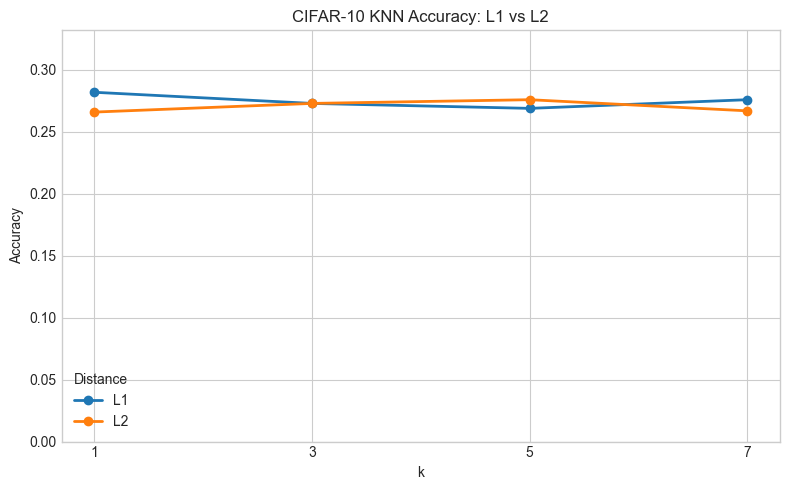

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

for metric in METRICS:
    metric_name = metric.upper()
    metric_results = [row for row in results if row['metric'] == metric_name]
    ax.plot(
        [row['k'] for row in metric_results],
        [row['accuracy'] for row in metric_results],
        marker='o',
        linewidth=2,
        label=metric_name,
    )

ax.set_title('CIFAR-10 KNN Accuracy: L1 vs L2')
ax.set_xlabel('k')
ax.set_ylabel('Accuracy')
ax.set_xticks(K_VALUES)
ax.set_ylim(0, max(row['accuracy'] for row in results) + 0.05)
ax.legend(title='Distance')
fig.tight_layout()
fig.savefig(RESULT_DIR / '5_cifar10_knn_l1_l2_accuracy.png', dpi=150)
plt.show()

## 4. Visualize KNN Decision Regions

CIFAR-10 images are 3072-dimensional pixel vectors, so the original KNN regions cannot be visualized directly. Instead, the training data is projected to two dimensions with PCA, and KNN decision regions are drawn on that 2D plane.

In [10]:
REGION_TRAIN_LIMIT = 1200
REGION_SCATTER_LIMIT = 350
REGION_K = 5
GRID_SIZE = 160

X_region = X_train[:REGION_TRAIN_LIMIT]
y_region = y_train_small[:REGION_TRAIN_LIMIT]

X_mean = X_region.mean(axis=0, keepdims=True)
X_centered = X_region - X_mean

# Use SVD to build 2D PCA coordinates.
_, _, vt = np.linalg.svd(X_centered, full_matrices=False)
components = vt[:2]
X_region_2d = X_centered @ components.T

x_min, x_max = X_region_2d[:, 0].min() - 1.0, X_region_2d[:, 0].max() + 1.0
y_min, y_max = X_region_2d[:, 1].min() - 1.0, X_region_2d[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, GRID_SIZE),
    np.linspace(y_min, y_max, GRID_SIZE),
)
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

print('PCA train points:', X_region_2d.shape)
print('Grid points:', grid_points.shape)

PCA train points: (1200, 2)
Grid points: (25600, 2)


C:\Users\lyw\AppData\Local\Temp\ipykernel_30156\2929564387.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


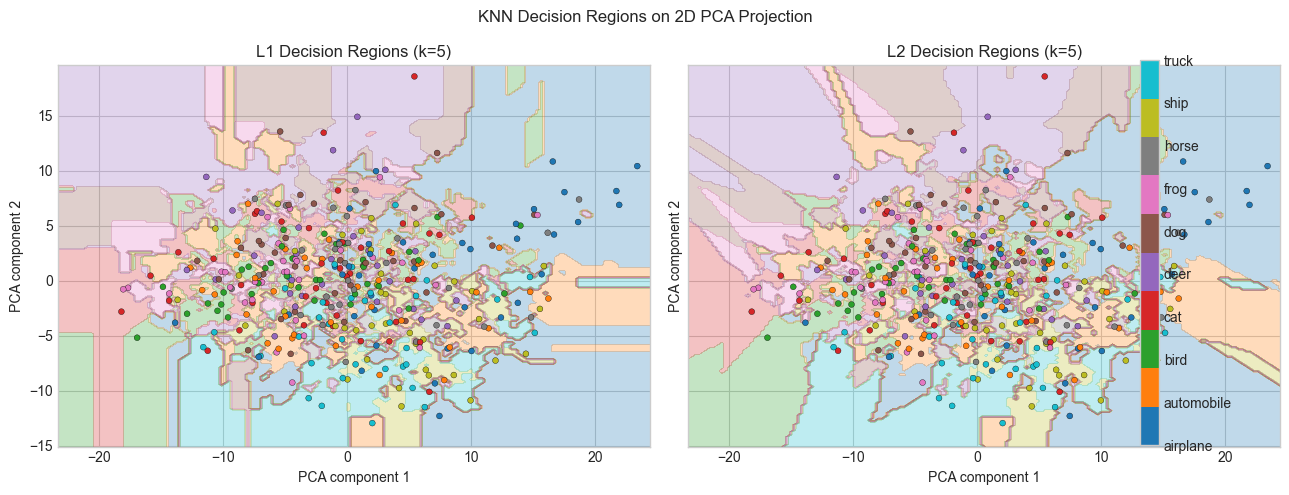

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
cmap = plt.get_cmap('tab10')
levels = np.arange(11) - 0.5

for ax, metric in zip(axes, ['l1', 'l2']):
    region_pred = knn_predict_many_k(
        X_region_2d.astype(np.float32),
        y_region,
        grid_points,
        k_values=[REGION_K],
        metric=metric,
        batch_size=1000,
    )[REGION_K]
    region_map = region_pred.reshape(xx.shape)

    ax.contourf(xx, yy, region_map, levels=levels, cmap=cmap, alpha=0.28)
    scatter = ax.scatter(
        X_region_2d[:REGION_SCATTER_LIMIT, 0],
        X_region_2d[:REGION_SCATTER_LIMIT, 1],
        c=y_region[:REGION_SCATTER_LIMIT],
        cmap=cmap,
        s=18,
        edgecolors='k',
        linewidths=0.25,
    )
    ax.set_title(f'{metric.upper()} Decision Regions (k={REGION_K})')
    ax.set_xlabel('PCA component 1')
    ax.set_ylabel('PCA component 2')

cbar = fig.colorbar(scatter, ax=axes, ticks=np.arange(10), fraction=0.025, pad=0.02)
cbar.ax.set_yticklabels(CIFAR10_LABELS)
fig.suptitle('KNN Decision Regions on 2D PCA Projection')
fig.tight_layout()
fig.savefig(RESULT_DIR / '5_cifar10_knn_decision_regions.png', dpi=150)
plt.show()

## 5. Analysis

- L1 distance sums the absolute differences between pixels, so it directly accumulates pixel-level changes.
- L2 distance squares differences before summing them, so large differences have a stronger effect.
- For images such as CIFAR-10, where background, position, and color vary significantly, simple pixel-based KNN has limited accuracy.
- `k=1` depends heavily on a single nearest image, while larger `k` values can make predictions more stable by voting across multiple neighbors.
- The final comparison uses the accuracy values in the table and graph to decide whether L1 or L2 performs better.
- The decision region plot is a visualization in the 2D PCA space, so it is not identical to the original 3072-dimensional KNN result, but it gives an intuitive view of how L1 and L2 form different classification boundaries.